### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.model_selection import RandomizedSearchCV

### Load Dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CSE427 - Machine Learning/student_stress_index_dataset.csv')

# df.head()

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=15J4vYIqRAGFj9YjG6N40mo26Gf_SHJlS')

df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Stress_Index
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,0.96,0.90,0.90,Year 1,Arts,High School,5.78
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,1.28,1.20,1.19,Year 3,Engineering,Bachelor,6.54
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,1.68,1.32,1.32,Year 1,Arts,Master,5.82
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,1.78,1.77,1.77,Year 1,CS,High School,NaN
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,1.48,0.91,0.87,Year 4,Business,Bachelor,6.79


# Exploratory Data Analysis (EDA)
* Descriptive Analysis
* Correlation Analysis

In [ ]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Stress_Index
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,0.96,0.90,0.90,Year 1,Arts,High School,5.78
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,1.28,1.20,1.19,Year 3,Engineering,Bachelor,6.54
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,1.68,1.32,1.32,Year 1,Arts,Master,5.82
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,1.78,1.77,1.77,Year 1,CS,High School,NaN
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,1.48,0.91,0.87,Year 4,Business,Bachelor,6.79


In [ ]:
print(f"the shape of the dataset is {df.shape}")
print(f"This dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

the shape of the dataset is (10000, 18)
This dataset contains 10000 rows and 18 columns.


In [ ]:
df.isna().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,500
Internet_Access,0
Study_Hours_per_Day,500
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Features

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  GPA                    10000 non-null  float64
 12  Semester_GPA           10000 non-null  float64
 13  CGPA                   10000 non-null  float64
 14  Semester               10000 non-null  object 
 15  Dep

In [ ]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,GPA,Semester_GPA,CGPA,Stress_Index
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,9500.000000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,2.308440,2.300057,2.298761,5.506968
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.061717,1.074407,1.072555,1.257421
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,0.000000,0.000000,0.000000,1.660000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,1.550000,1.520000,1.520000,4.640000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,2.350000,2.350000,2.350000,5.530000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,3.120000,3.150000,3.150000,6.370000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,4.000000,4.000000,4.000000,9.180000


In [ ]:
# Storing 'Student_ID' for future references
student_id = df['Student_ID']
df = df.drop('Student_ID', axis=1)
df

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Stress_Index
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,0.96,0.90,0.90,Year 1,Arts,High School,5.78
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,1.28,1.20,1.19,Year 3,Engineering,Bachelor,6.54
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,1.68,1.32,1.32,Year 1,Arts,Master,5.82
3,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,1.78,1.77,1.77,Year 1,CS,High School,NaN
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,1.48,0.91,0.87,Year 4,Business,Bachelor,6.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,1.60,0.99,0.97,Year 2,Arts,Bachelor,5.66
9996,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,3.09,3.09,3.09,Year 1,Business,Master,5.88
9997,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.45,3.37,3.43,Year 4,Business,Bachelor,4.02
9998,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,3.35,3.34,3.34,Year 1,CS,High School,5.79


## Splitting Categorical and Numerical Features

In [ ]:
numerical_data = df.select_dtypes(include='number')

print(f"this dataset has {numerical_data.shape[1]} numerical features:")
numerical_features = numerical_data.columns.tolist()
print(numerical_features)

this dataset has 10 numerical features:
['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'GPA', 'Semester_GPA', 'CGPA', 'Stress_Index']


In [ ]:
categorical_data = df.select_dtypes(include='object')

print(f"this dataset has {categorical_data.shape[1]} categorical features")
categorical_features = categorical_data.columns.tolist()
print(categorical_features)

this dataset has 7 categorical features
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


### Number of Unique Values in Features

In [ ]:
numerical_data.nunique()

,0
Age,115
Family_Income,5438
Study_Hours_per_Day,702
Attendance_Rate,440
Assignment_Delay_Days,9
Travel_Time_Minutes,589
GPA,401
Semester_GPA,401
CGPA,401
Stress_Index,682


In [ ]:
categorical_data.nunique()

,0
Gender,2
Internet_Access,2
Part_Time_Job,2
Scholarship,2
Semester,4
Department,5
Parental_Education,4


## 1. Descriptive Analysis

### Numerical data

In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,21.026060,2.139810,17.00,19.50,21.00,22.50,29.60
Family_Income,9500.0,38377.247474,20496.232179,25000.00,25000.00,29740.50,44520.00,316601.00
Study_Hours_per_Day,9500.0,4.014592,1.295450,0.50,3.16,4.00,4.87,8.98
Attendance_Rate,10000.0,81.736830,8.220930,38.20,76.40,81.80,87.30,100.00
Assignment_Delay_Days,10000.0,1.799700,1.344307,0.00,1.00,2.00,3.00,8.00
Travel_Time_Minutes,10000.0,30.179260,11.918870,5.00,21.90,30.20,38.40,74.90
GPA,10000.0,2.308440,1.061717,0.00,1.55,2.35,3.12,4.00
Semester_GPA,10000.0,2.300057,1.074407,0.00,1.52,2.35,3.15,4.00
CGPA,10000.0,2.298761,1.072555,0.00,1.52,2.35,3.15,4.00
Stress_Index,9500.0,5.506968,1.257421,1.66,4.64,5.53,6.37,9.18


In [ ]:
# Variance of numerical data
numerical_data.var()

,0
Age,4.578787e+00
Family_Income,4.200955e+08
Study_Hours_per_Day,1.678191e+00
Attendance_Rate,6.758368e+01
Assignment_Delay_Days,1.807161e+00
Travel_Time_Minutes,1.420595e+02
GPA,1.127242e+00
Semester_GPA,1.154350e+00
CGPA,1.150374e+00
Stress_Index,1.581107e+00


In [ ]:
numerical_data.skew()

,0
Age,0.183220
Family_Income,2.826862
Study_Hours_per_Day,0.031494
Attendance_Rate,-0.172013
Assignment_Delay_Days,0.704404
Travel_Time_Minutes,0.094107
GPA,-0.197937
Semester_GPA,-0.221748
CGPA,-0.224939
Stress_Index,-0.040125


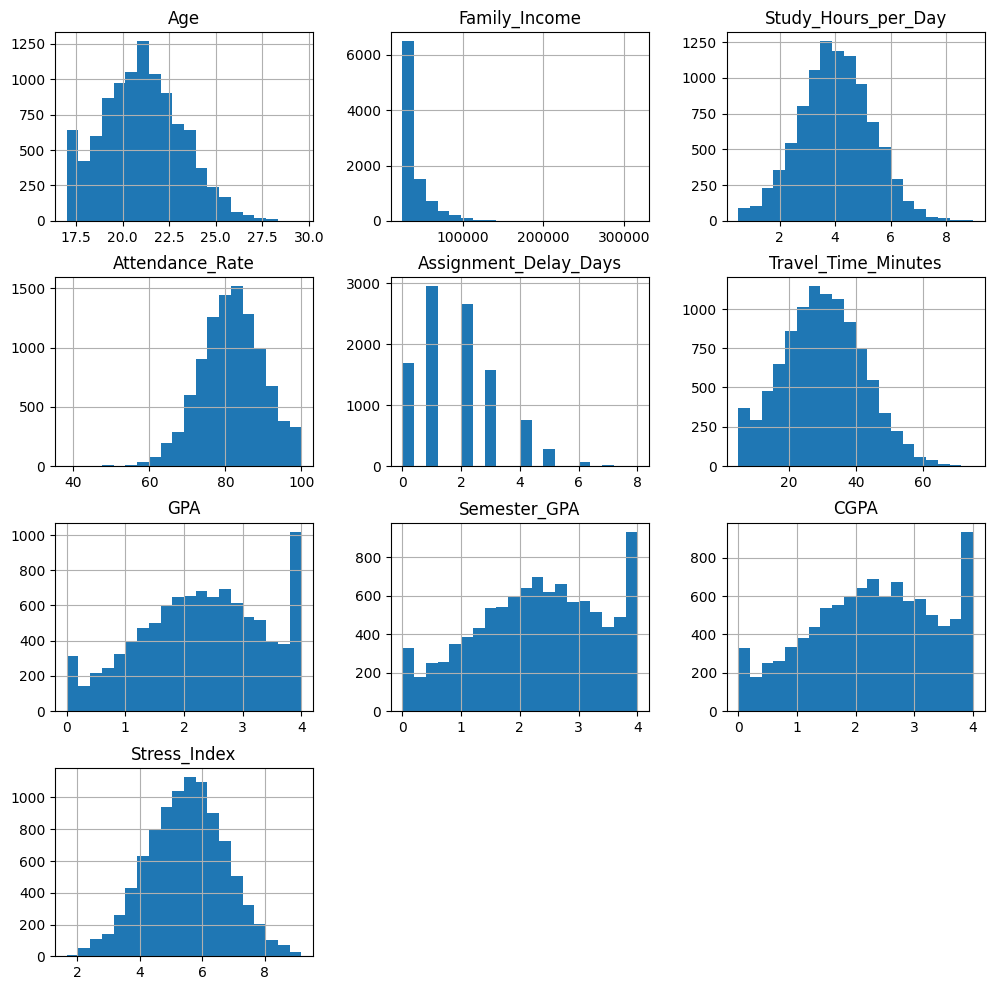

In [ ]:
numerical_data.hist(figsize=(12, 12), bins=20)
plt.show()

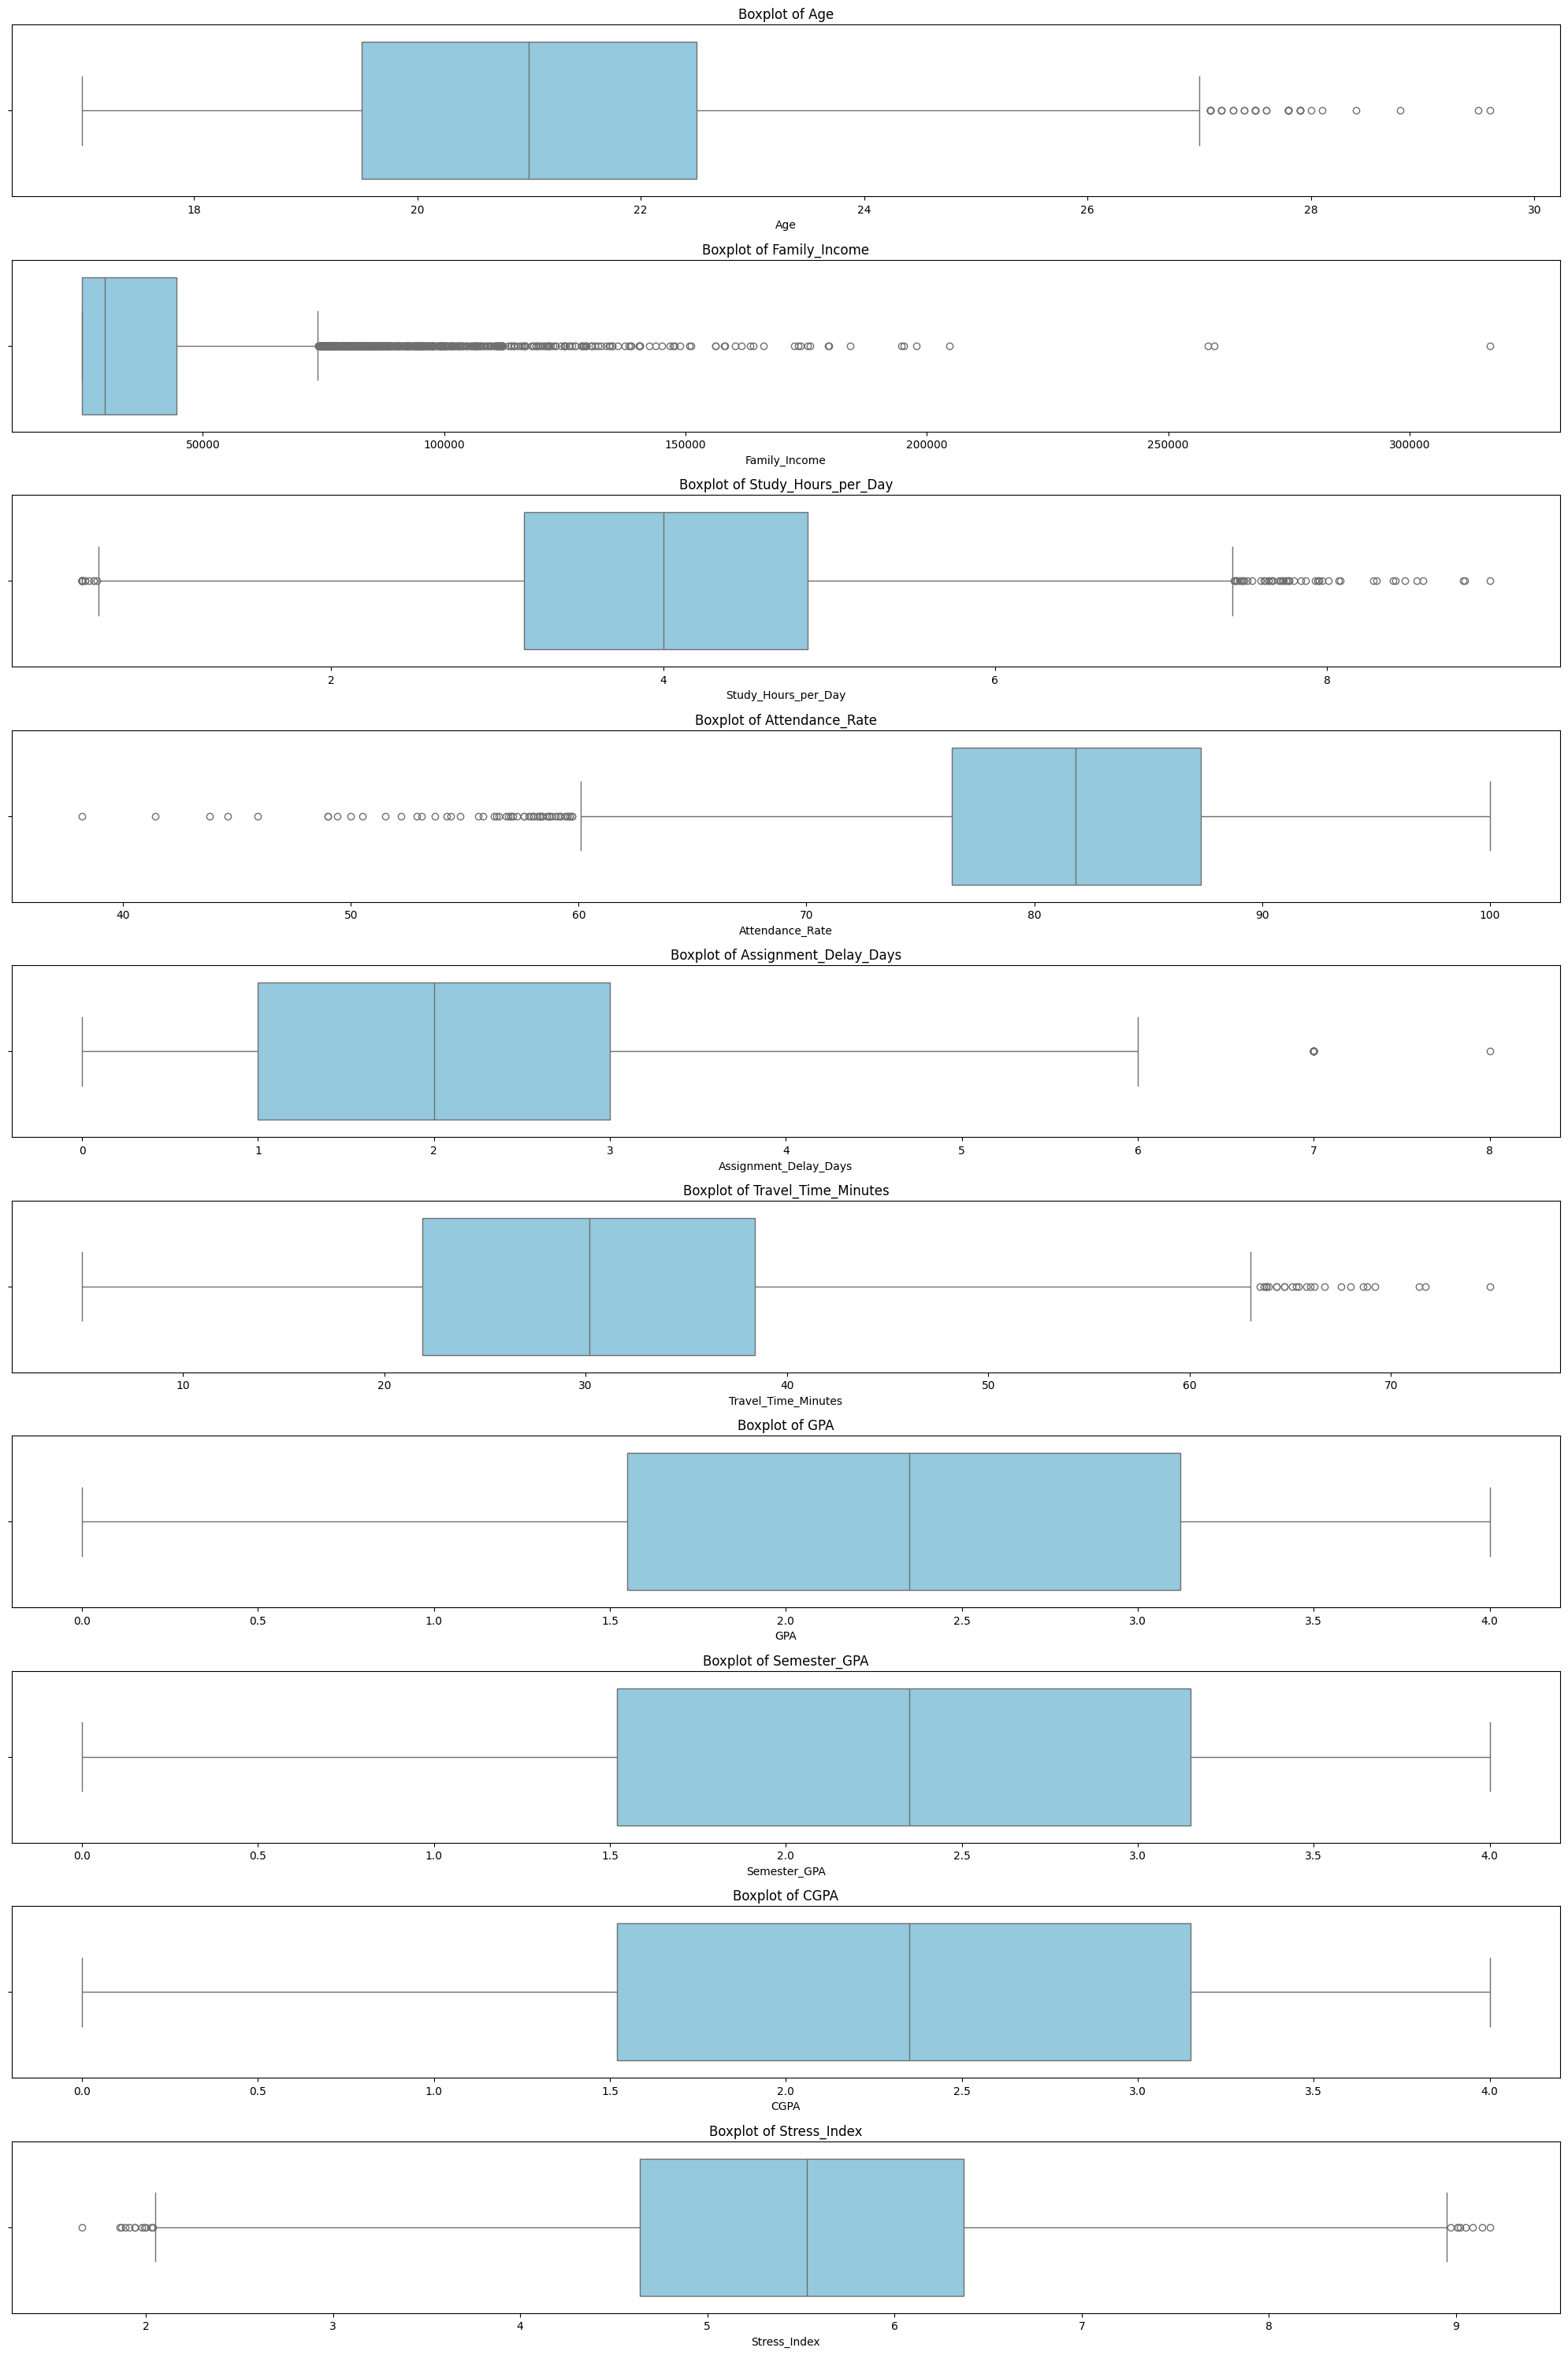

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
plt.figure(figsize=(20, 30))

# Plot boxplots for each numerical feature including the target variable 'Stress Index'
for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)

plt.tight_layout()
plt.show()


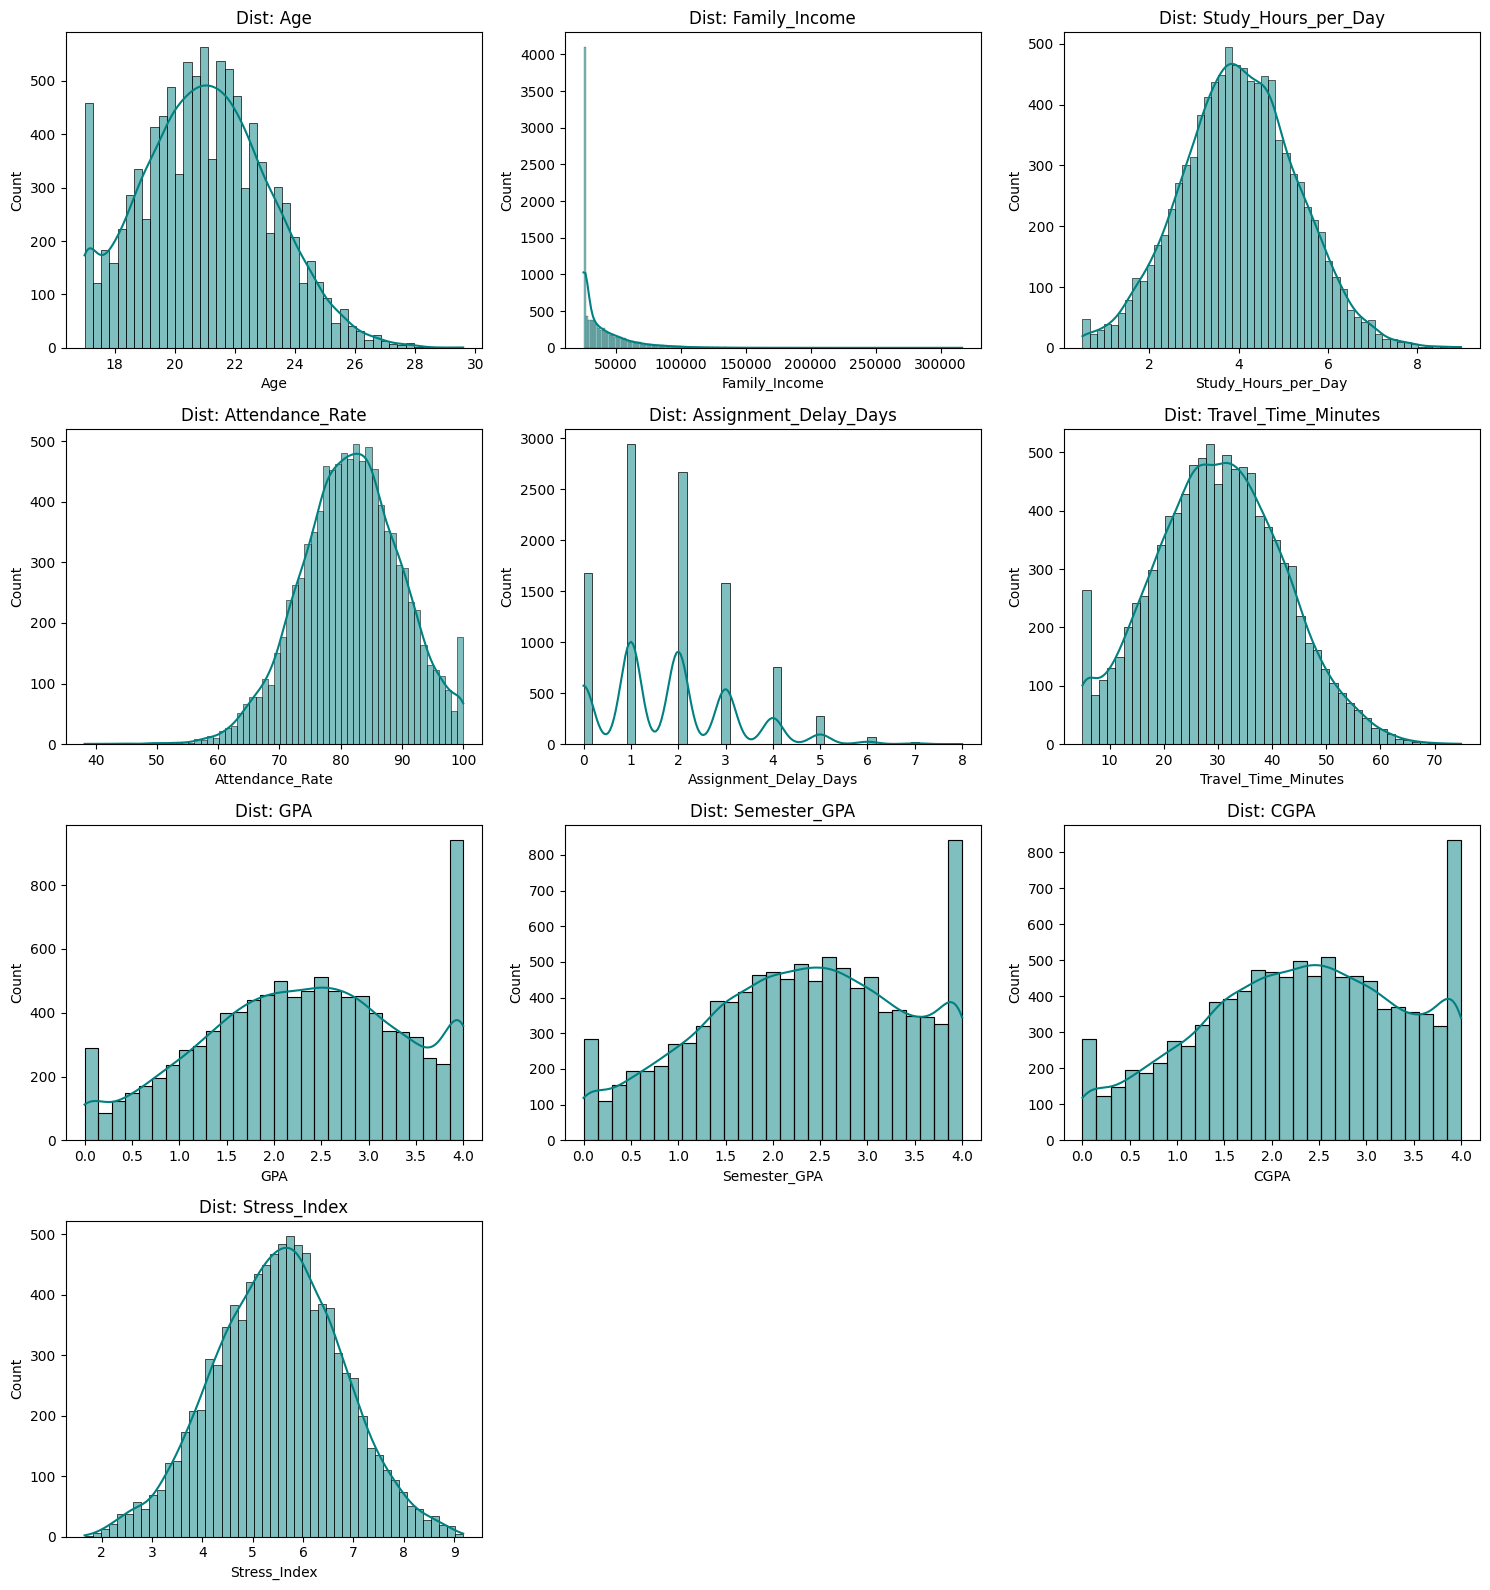

In [ ]:
num_features = len(numerical_features)
n_cols = 3
n_rows = math.ceil(num_features / n_cols)

# Create the specific grid of subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Dist: {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

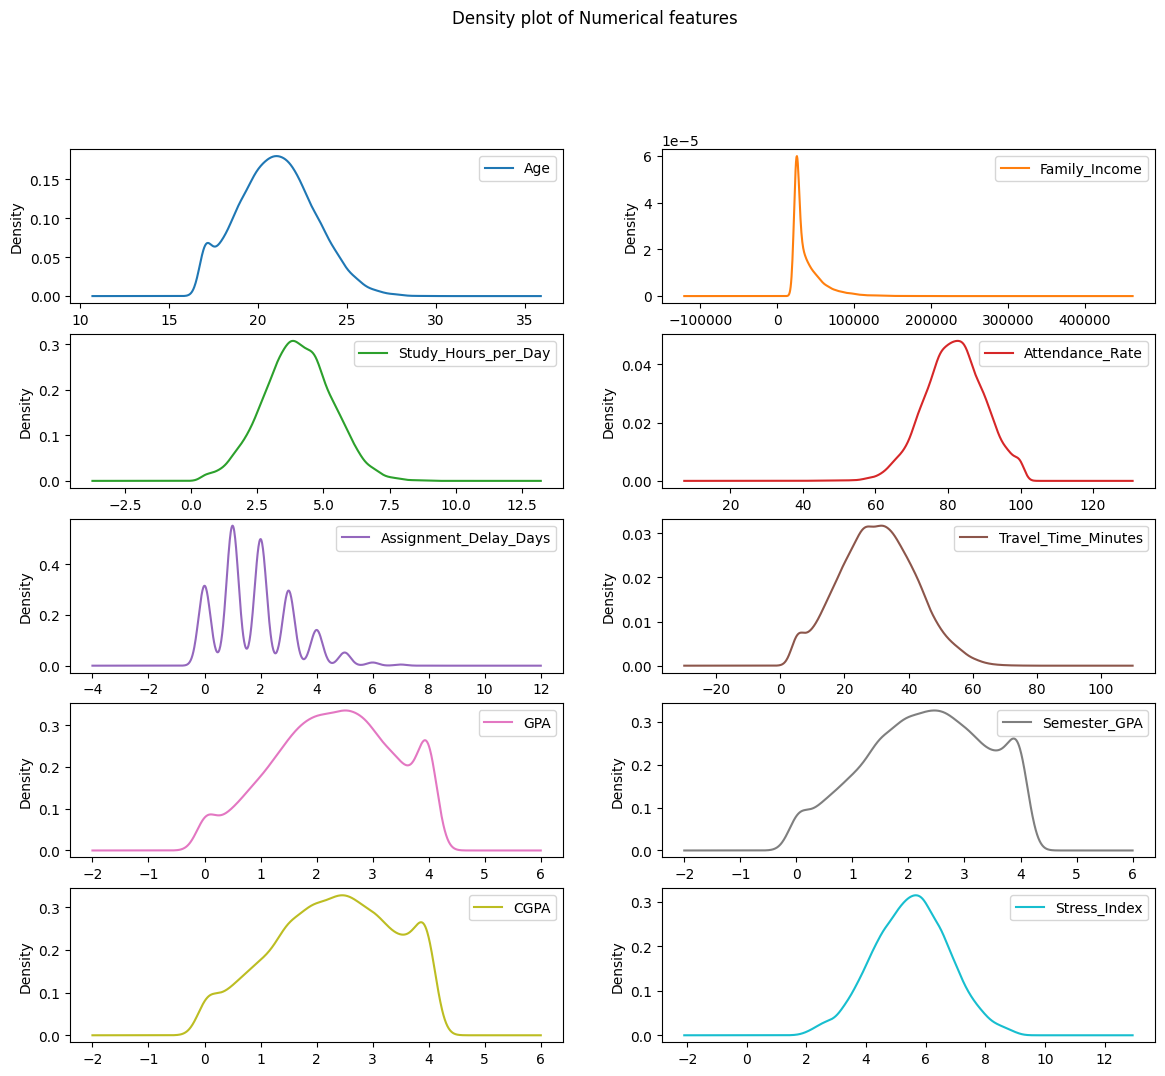

In [ ]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

### Categorical Data

In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Gender,10000,2,Female,5011
Internet_Access,10000,2,Yes,8769
Part_Time_Job,10000,2,No,5996
Scholarship,10000,2,No,6489
Semester,10000,4,Year 4,2536
Department,10000,5,Science,2061
Parental_Education,9489,4,Bachelor,3949


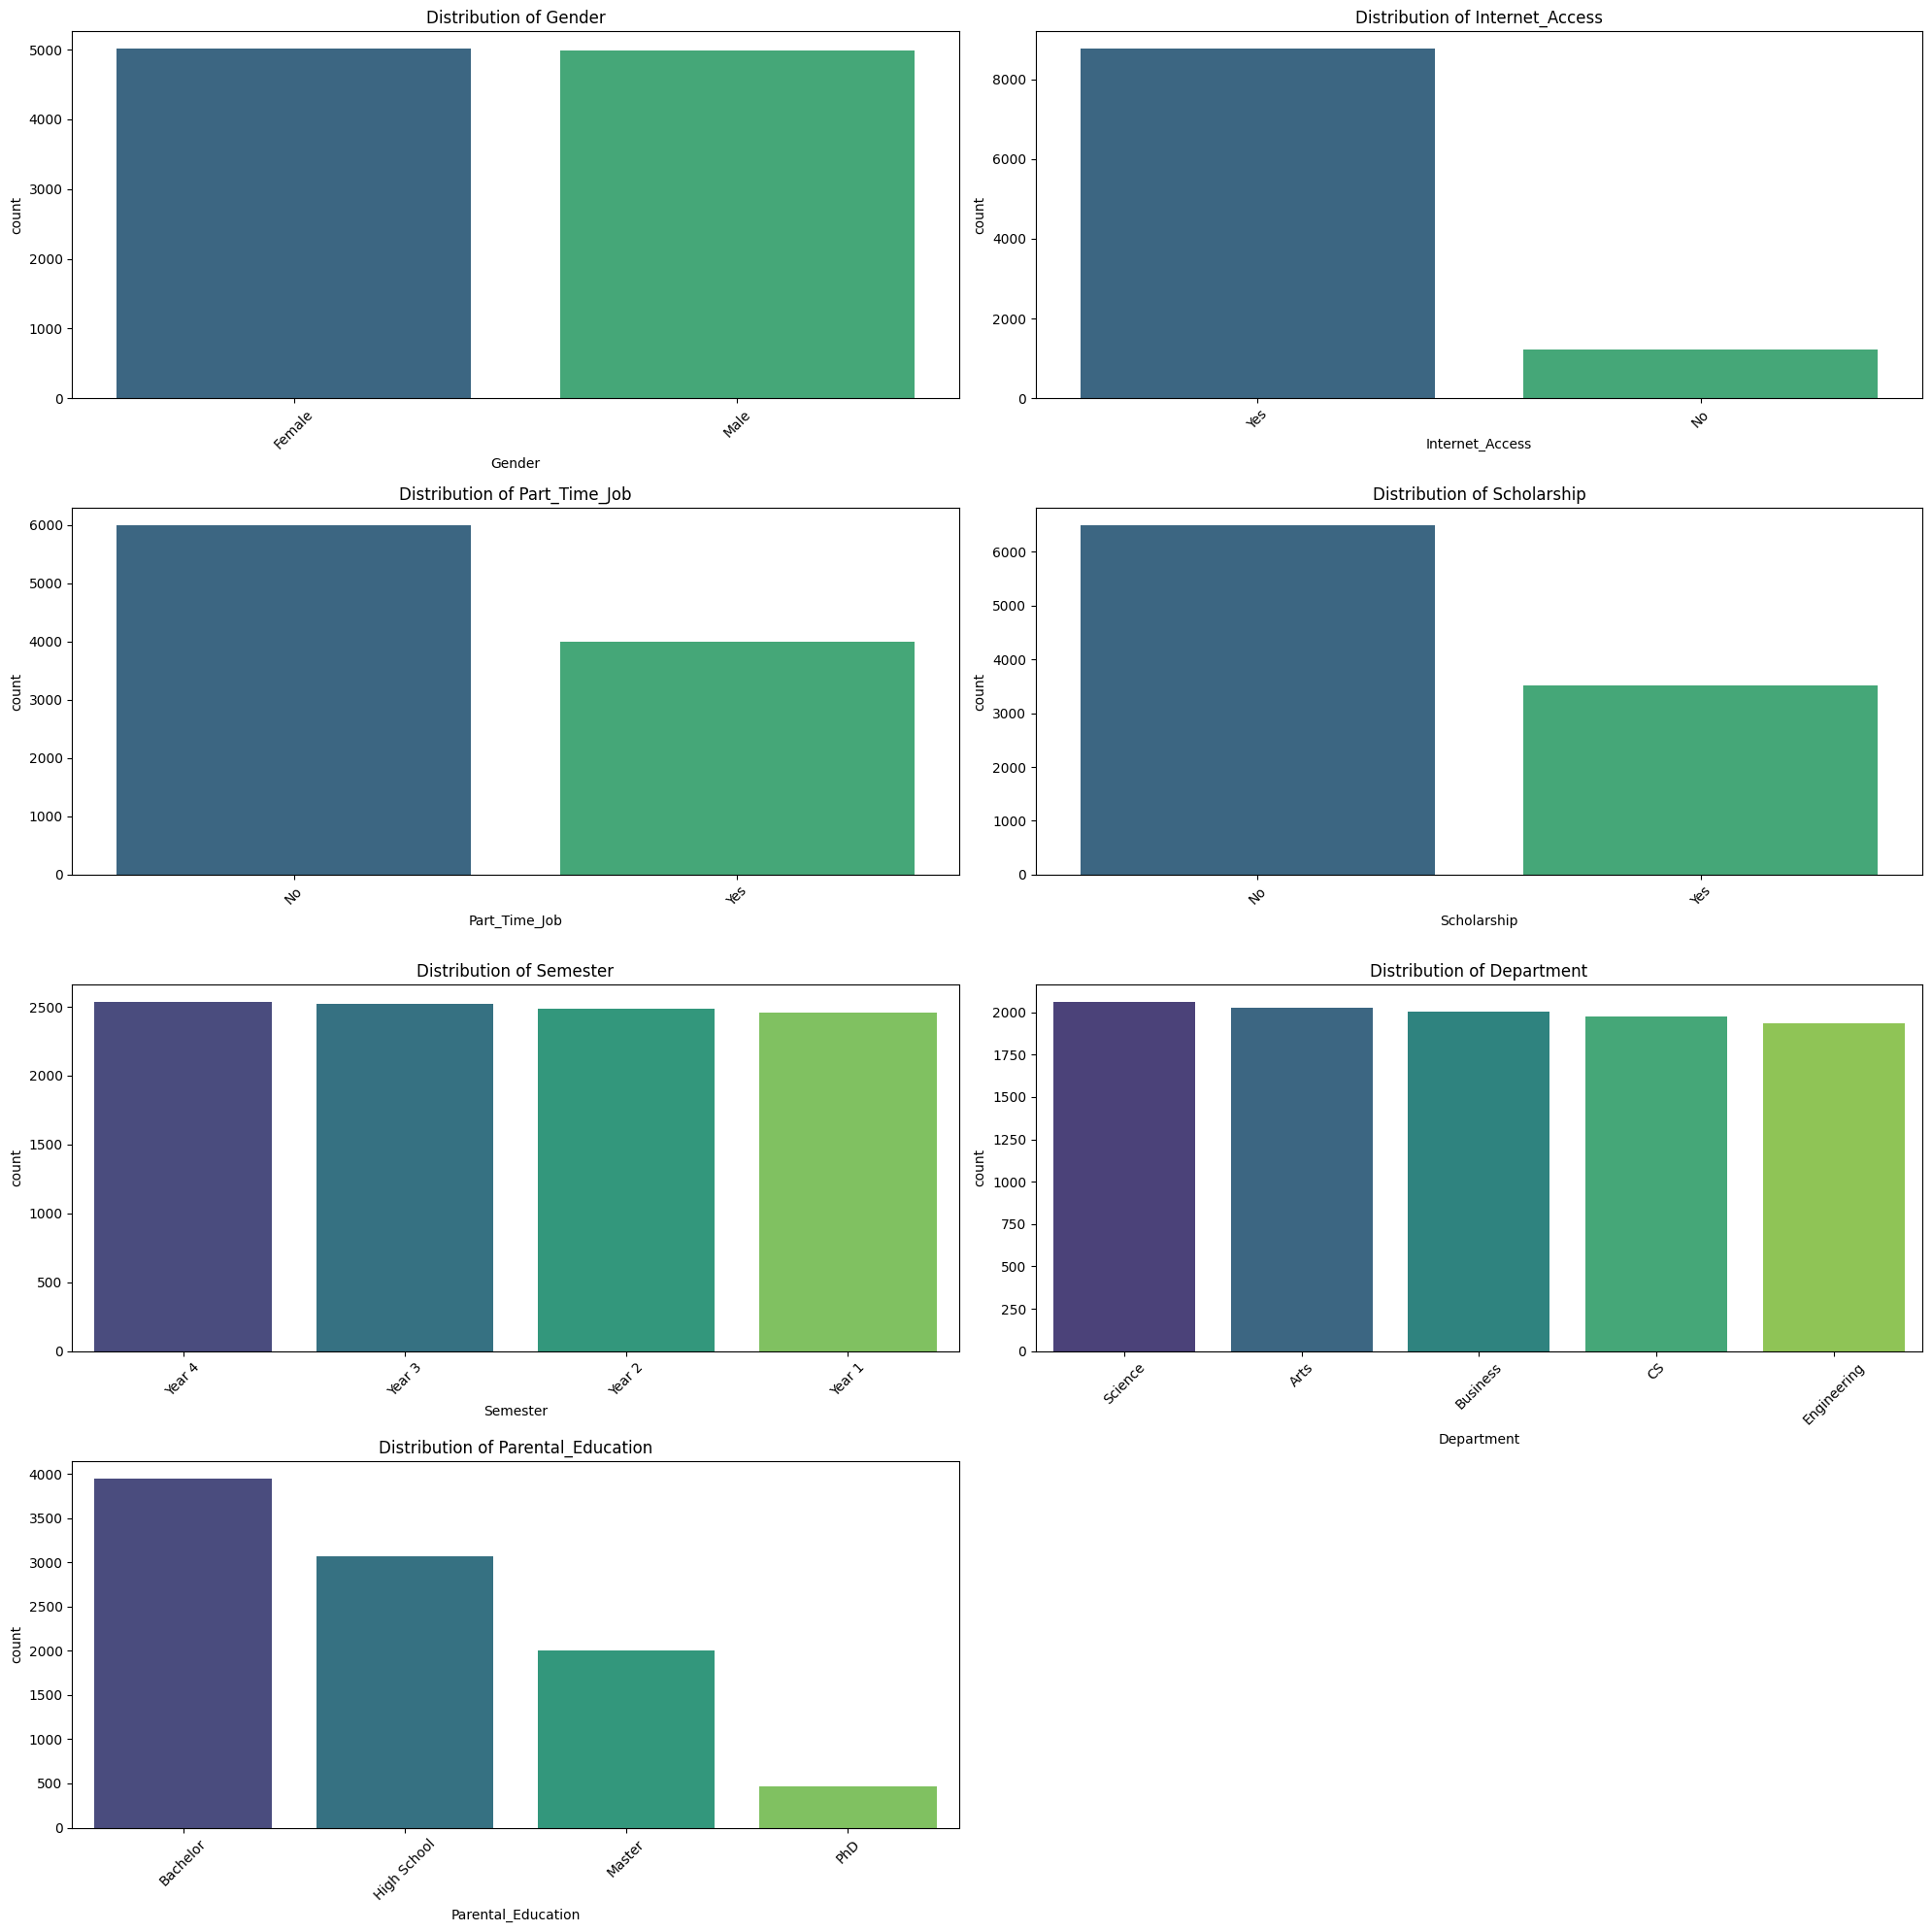

In [ ]:
n_rows = (len(categorical_features) + 1) // 2
plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(categorical_features):
    plt.subplot(n_rows, 2, i + 1)

    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='viridis')

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Target Feature Analysis

In [ ]:
print(f"Mean:   {df['Stress_Index'].mean():.2f}")
print(f"Median: {df['Stress_Index'].median():.2f}")
print(f"Min:    {df['Stress_Index'].min():.2f}")
print(f"Max:    {df['Stress_Index'].max():.2f}")
print(f"Std Dev:{df['Stress_Index'].std():.2f}")
print(f"Skew:   {df['Stress_Index'].skew():.2f}")

Mean:   5.51
Median: 5.53
Min:    1.66
Max:    9.18
Std Dev:1.26
Skew:   -0.04


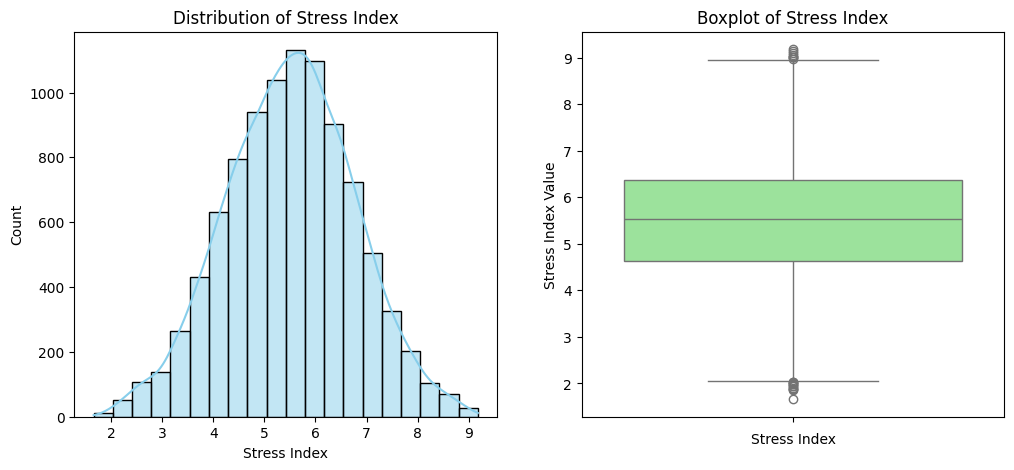

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Stress_Index'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Stress Index')
plt.xlabel('Stress Index')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Stress_Index'], color='lightgreen')
plt.title('Boxplot of Stress Index')
plt.xlabel('Stress Index')
plt.ylabel('Stress Index Value')

plt.show()

### Target Feature vs Categorical Data

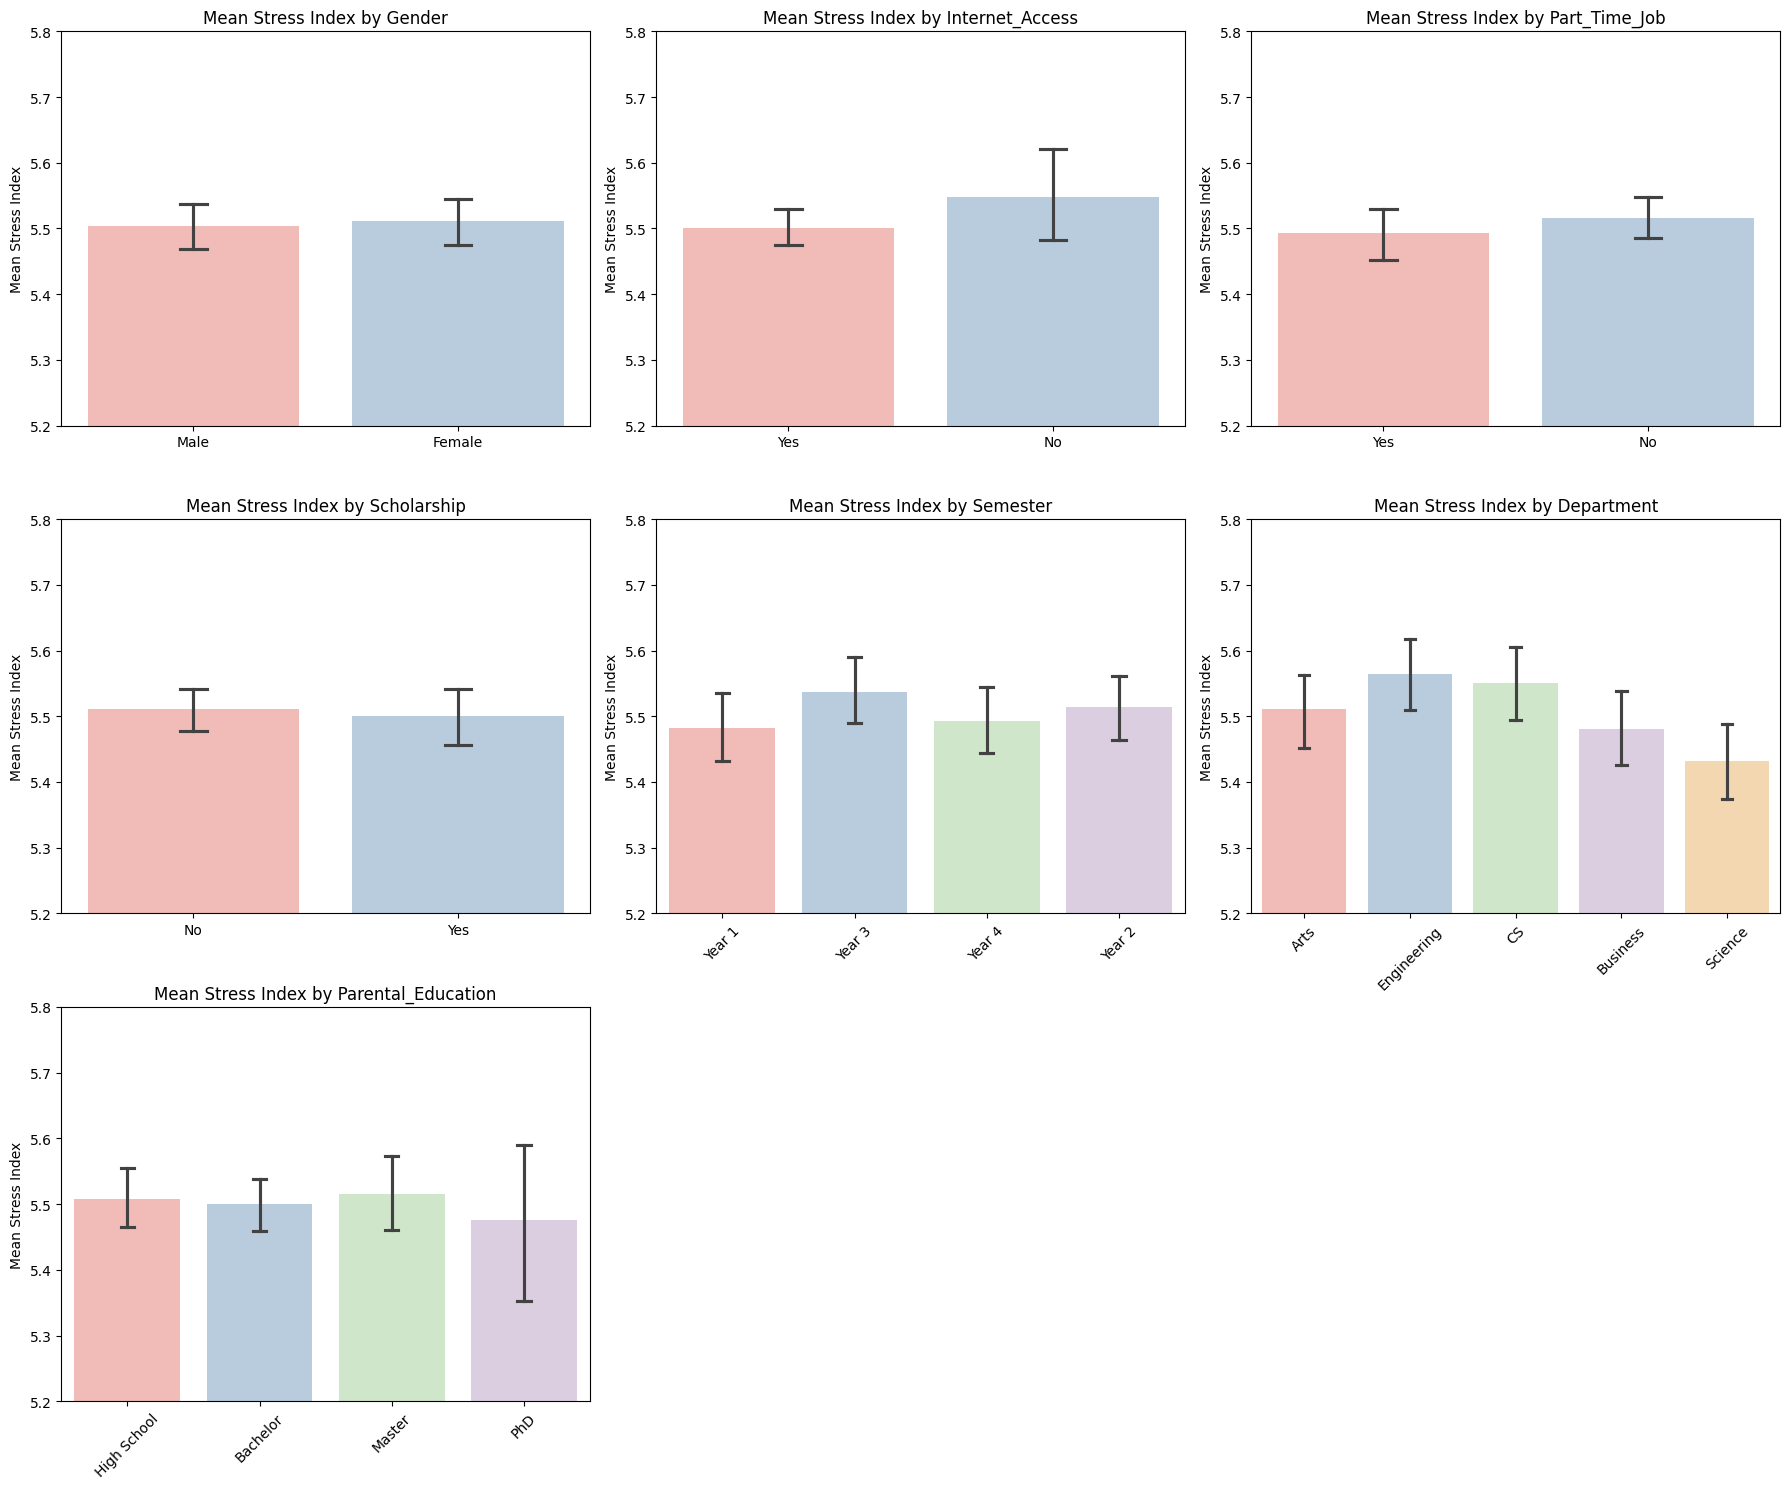

In [ ]:
n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.barplot(data=df, x=col, y='Stress_Index', ax=axes[i], palette='Pastel1', errorbar=('ci', 95), capsize=0.1)

    axes[i].set_title(f'Mean Stress Index by {col}', fontsize=12)
    axes[i].set_ylabel('Mean Stress Index')
    axes[i].set_xlabel('')

    axes[i].set_ylim(5.2, 5.8)

    if df[col].nunique() > 3:
        axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Target Feature vs Numerical Data

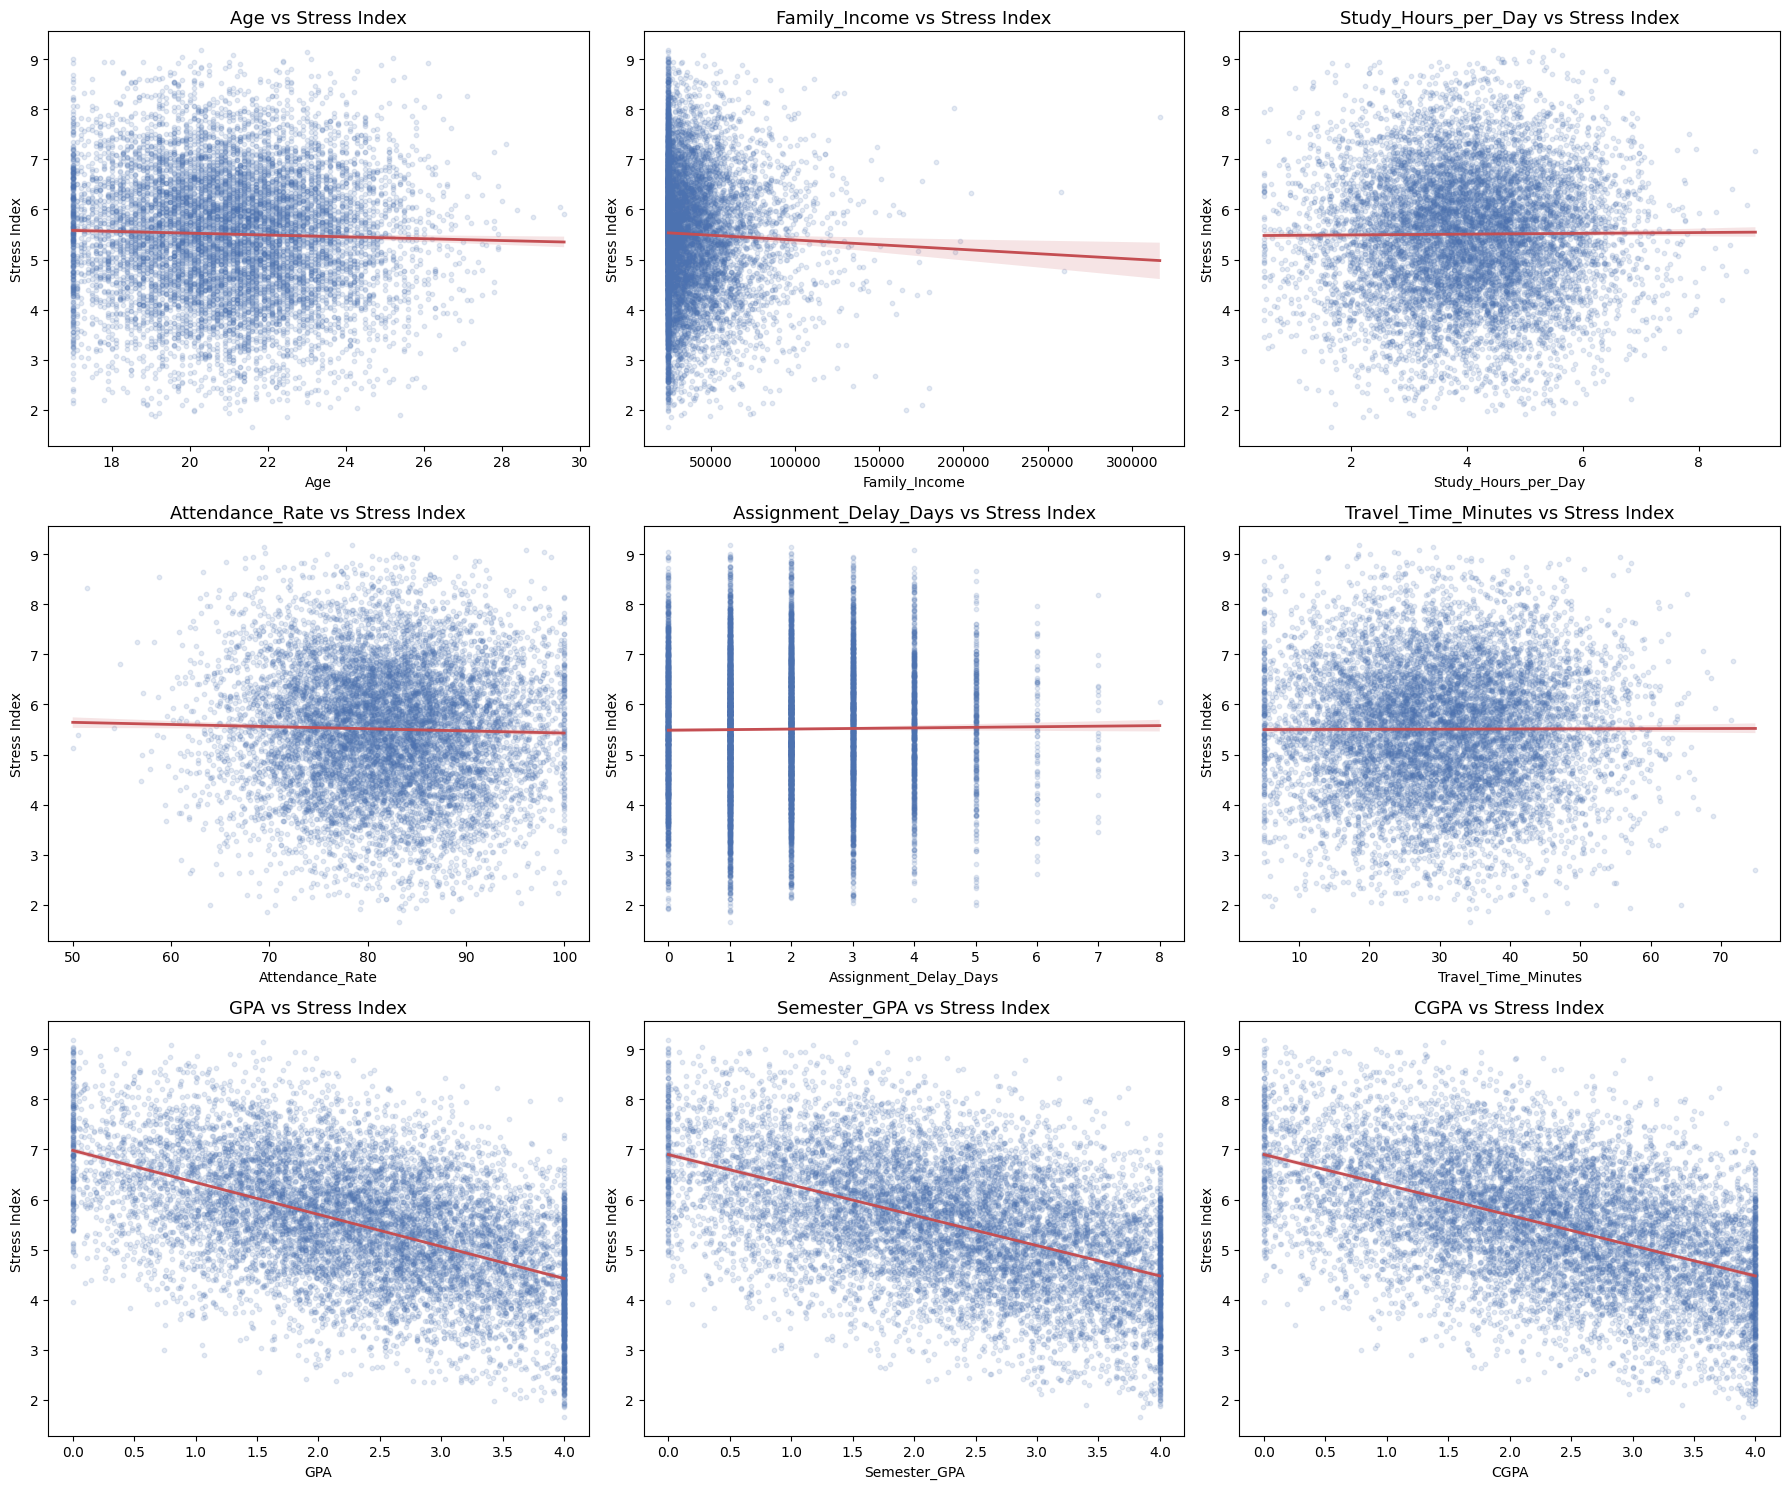

In [ ]:
numeric_cols = [i for i in numerical_features if i != 'Stress_Index']
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.regplot(data=df, x=col, y='Stress_Index', ax=axes[i],
                scatter_kws={'alpha': 0.15, 'color': '#4C72B0', 's': 10},
                line_kws={'color': '#C44E52', 'linewidth': 2})

    axes[i].set_title(f'{col} vs Stress Index', fontsize=13)
    axes[i].set_ylabel('Stress Index')
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Missing Data Analysis

In [ ]:
missing_count = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent
}).sort_values(by='Missing Count', ascending=False)

print(missing_summary)

                       Missing Count  Missing Percent
Parental_Education               511             5.11
Stress_Index                     500             5.00
Family_Income                    500             5.00
Study_Hours_per_Day              500             5.00
Age                                0             0.00
Attendance_Rate                    0             0.00
Assignment_Delay_Days              0             0.00
Gender                             0             0.00
Internet_Access                    0             0.00
Part_Time_Job                      0             0.00
Travel_Time_Minutes                0             0.00
Scholarship                        0             0.00
GPA                                0             0.00
CGPA                               0             0.00
Semester_GPA                       0             0.00
Department                         0             0.00
Semester                           0             0.00


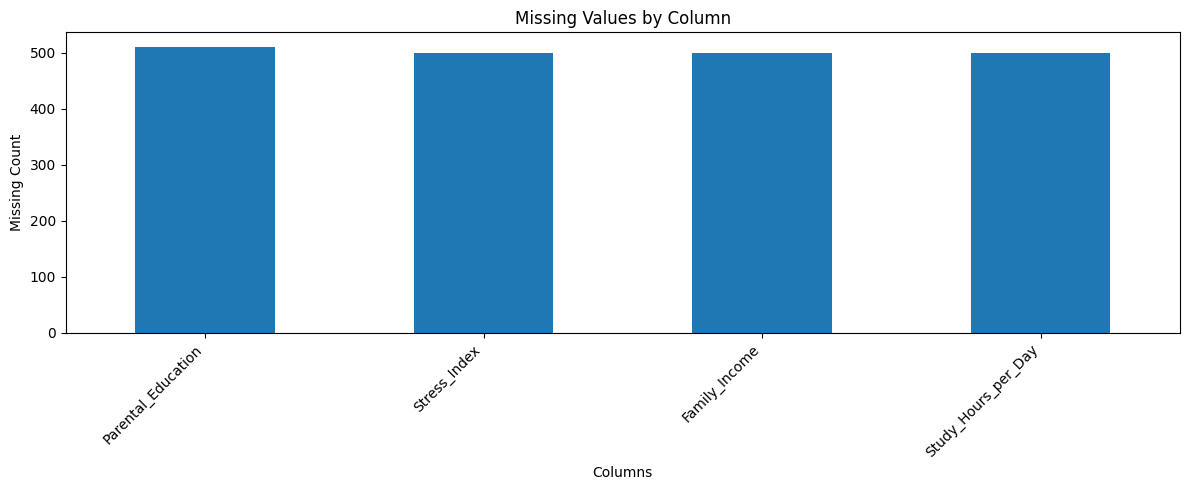

In [ ]:
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

plt.figure(figsize=(12, 5))
missing_summary['Missing Count'].plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Correlation Analysis

In [ ]:
# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()
correlation_matrix

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,GPA,Semester_GPA,CGPA,Stress_Index
Age,1.000000,0.008366,0.001722,0.011307,0.012405,-0.014714,-0.010184,-0.009947,-0.010478,-0.031246
Family_Income,0.008366,1.000000,0.003867,-0.008219,0.007179,0.018514,-0.000808,0.002917,0.001882,-0.030934
Study_Hours_per_Day,0.001722,0.003867,1.000000,-0.015778,0.000259,0.011599,0.214687,0.207719,0.208077,0.008138
Attendance_Rate,0.011307,-0.008219,-0.015778,1.000000,-0.009601,0.015214,0.206739,0.197346,0.197620,-0.027072
Assignment_Delay_Days,0.012405,0.007179,0.000259,-0.009601,1.000000,-0.000300,-0.029449,-0.024166,-0.024580,0.012377
Travel_Time_Minutes,-0.014714,0.018514,0.011599,0.015214,-0.000300,1.000000,0.013925,0.011190,0.011841,0.003065
GPA,-0.010184,-0.000808,0.214687,0.206739,-0.029449,0.013925,1.000000,0.964275,0.963432,-0.540243
Semester_GPA,-0.009947,0.002917,0.207719,0.197346,-0.024166,0.011190,0.964275,1.000000,0.999214,-0.517173
CGPA,-0.010478,0.001882,0.208077,0.197620,-0.024580,0.011841,0.963432,0.999214,1.000000,-0.516819
Stress_Index,-0.031246,-0.030934,0.008138,-0.027072,0.012377,0.003065,-0.540243,-0.517173,-0.516819,1.000000


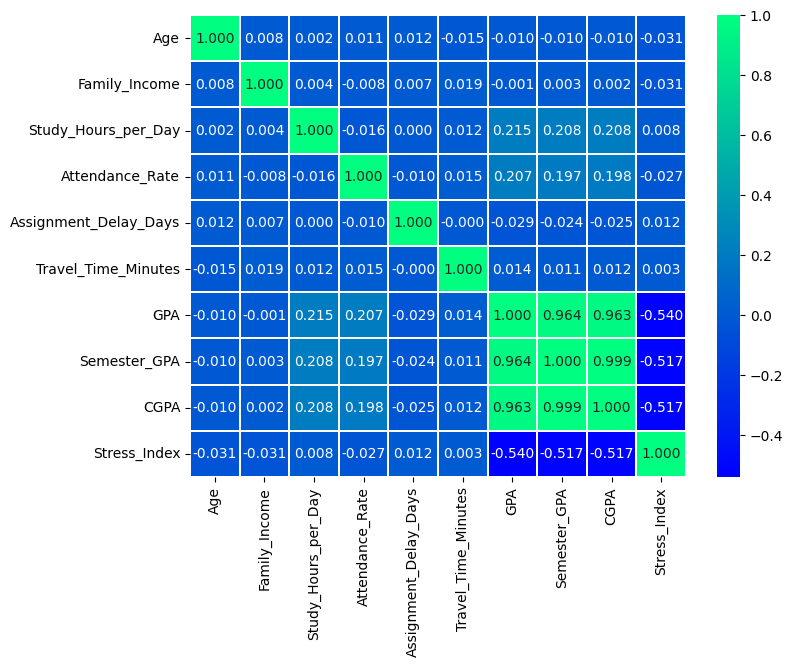

In [ ]:
# Plotting the heatmap for correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='winter', fmt='.3f', linewidths=0.3)
plt.show()

# Dataset Pre-Processing

In [ ]:
df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Stress_Index
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,0.96,0.90,0.90,Year 1,Arts,High School,5.78
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,1.28,1.20,1.19,Year 3,Engineering,Bachelor,6.54
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,1.68,1.32,1.32,Year 1,Arts,Master,5.82
3,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,1.78,1.77,1.77,Year 1,CS,High School,NaN
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,1.48,0.91,0.87,Year 4,Business,Bachelor,6.79


In [ ]:
# Removing the null values in the target column
df = df.dropna(subset=['Stress_Index'])
df['Stress_Index'].shape

(9500,)

In [ ]:
# Feature Engineering

# Academic Risk ranges between 0 to 3
df["Academic_Risk"] = (
    (df["Attendance_Rate"] < 75).astype(int)
    + (df["Study_Hours_per_Day"] < 2).astype(int)
    + (df["Assignment_Delay_Days"] > 5).astype(int)
)

In [ ]:
num_skewed = ['Family_Income']
num_normal = ['Age', 'Study_Hours_per_Day', 'CGPA', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Academic_Risk']

cat_ordinal = ['Semester', 'Parental_Education']
cat_nominal = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Department']

In [ ]:
# Pipeline for skewed numerical features
skewed_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

# Pipeline for normal numerical features
normal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline for ordinal categorical features
semester_order = ['Year 1', 'Year 2', 'Year 3', 'Year 4']
education_order = ['High School', 'Bachelor', 'Master', 'PhD']

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[semester_order, education_order]))
])

# Pipeline for nominal categorical features
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num_skew', skewed_transformer, num_skewed),
        ('num_norm', normal_transformer, num_normal),
        ('cat_ord', ordinal_transformer, cat_ordinal),
        ('cat_nom', nominal_transformer, cat_nominal)
    ],
    remainder='passthrough'
)

In [ ]:
X = df.drop(['Stress_Index'], axis=1)
y = df['Stress_Index']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Implementation

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_base = Pipeline([
  ('preprocessing', preprocessor),
  ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_base.fit(X_train, y_train)

y_pred_rf = rf_base.predict(X_test)

In [ ]:
rf_tuned = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions={
        'model__n_estimators': [100, 200, 300, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)


rf_tuned.fit(X_train, y_train)
tuned_rf_pipeline = rf_tuned.best_estimator_

y_pred_tuned_rf = tuned_rf_pipeline.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


### Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

In [ ]:
adaboost_base = Pipeline([
    ('preprocessing', preprocessor),
    ('model', AdaBoostRegressor(n_estimators=100, random_state=42))
])

adaboost_base.fit(X_train, y_train)

y_pred_ada = adaboost_base.predict(X_test)

In [ ]:
ada_tuned = RandomizedSearchCV(
    estimator=adaboost_base,
    param_distributions={
        'model__n_estimators': [50, 100, 200, 300, 500],
        'model__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
        'model__loss': ['linear', 'square', 'exponential']
    },
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

ada_tuned.fit(X_train, y_train)
tuned_ada_pipeline = ada_tuned.best_estimator_

y_pred_tuned_ada = tuned_ada_pipeline.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


### XGBoost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_base = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1))
])

xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)

In [ ]:
xgb_tuned = RandomizedSearchCV(
              estimator=xgb_base,
              param_distributions={
                'model__n_estimators': [100, 200, 300, 500],
                'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
                'model__max_depth': [3, 5, 7, 9],
                'model__subsample': [0.7, 0.8, 0.9, 1.0],
                'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
              }, n_iter=20, scoring='neg_mean_squared_error', cv=5, verbose=1, random_state=42, n_jobs=-1
    )

xgb_tuned.fit(X_train, y_train)
tuned_xgb_pipeline = xgb_tuned.best_estimator_

y_pred_tuned_xgb = tuned_xgb_pipeline.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


### K-Nearest Neighbour

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])

knn_base.fit(X_train, y_train)

y_pred_knn = knn_base.predict(X_test)

In [ ]:
knn_tuned = RandomizedSearchCV(
              estimator=knn_base,
              param_distributions={
                'model__n_neighbors': [3, 5, 7, 9, 11, 15],
                'model__weights': ['uniform', 'distance'],
                'model__p': [1, 2]
              }, n_iter=20, scoring='neg_mean_squared_error', cv=5, verbose=1, random_state=42, n_jobs=-1
    )

knn_tuned.fit(X_train, y_train)
tuned_knn_pipeline = knn_tuned.best_estimator_

y_pred_tuned_knn = tuned_knn_pipeline.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


### Multi Layer Perceptron (MLP)

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
mlp_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(max_iter=500, random_state=42))
])

mlp_base.fit(X_train, y_train)

y_pred_mlp = mlp_base.predict(X_test)

In [ ]:
mlp_tuned = RandomizedSearchCV(
              estimator=mlp_base,
              param_distributions={
                'model__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
                'model__activation': ['relu', 'tanh', 'logistic'],
                'model__alpha': [0.0001, 0.001, 0.01, 0.1],
                'model__learning_rate_init': [0.001, 0.01]
              }, n_iter=20, scoring='neg_mean_squared_error', cv=5, verbose=1, random_state=42, n_jobs=-1
    )

mlp_tuned.fit(X_train, y_train)
tuned_mlp_pipeline = mlp_tuned.best_estimator_

y_pred_tuned_mlp = tuned_mlp_pipeline.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


### Bayesian Ridge Regression

In [ ]:
from sklearn.linear_model import BayesianRidge

In [ ]:
bayesian_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', BayesianRidge())
])

bayesian_base.fit(X_train, y_train)

y_pred_bayesian = bayesian_base.predict(X_test)

In [ ]:
bayesian_tuned = RandomizedSearchCV(
              estimator=bayesian_base,
              param_distributions={
                'model__alpha_1': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
                'model__alpha_2': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
                'model__lambda_1': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
                'model__lambda_2': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
              }, n_iter=20, scoring='neg_mean_squared_error', cv=5, verbose=1, random_state=42, n_jobs=-1
    )

bayesian_tuned.fit(X_train, y_train)
tuned_bayesian_pipeline = bayesian_tuned.best_estimator_

y_pred_tuned_bayesian = tuned_bayesian_pipeline.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


# Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def model_evaluation(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Model name: {model_name}\n")
    print(f"MAE  (Mean Absolute Error)      : {mae:.4f}")
    print(f"MSE  (Mean Squared Error)       : {mse:.4f}")
    print(f"RMSE (Root Mean Squared Error)  : {rmse:.4f}")
    print(f"R^2  (R-squared)                : {r2:.4f}")


In [ ]:
model_evaluation("Random Forest Regressor", y_test, y_pred_rf)

Model name: Random Forest Regressor

MAE  (Mean Absolute Error)      : 0.8079
MSE  (Mean Squared Error)       : 1.0223
RMSE (Root Mean Squared Error)  : 1.0111
R^2  (R-squared)                : 0.3506


In [ ]:
model_evaluation("Tuned Random Forest", y_test, y_pred_tuned_rf)

Model name: Tuned Random Forest

MAE  (Mean Absolute Error)      : 0.8052
MSE  (Mean Squared Error)       : 1.0170
RMSE (Root Mean Squared Error)  : 1.0085
R^2  (R-squared)                : 0.3539


In [ ]:
model_evaluation("AdaBoost Regressor", y_test, y_pred_ada)

Model name: AdaBoost Regressor

MAE  (Mean Absolute Error)      : 0.8300
MSE  (Mean Squared Error)       : 1.0657
RMSE (Root Mean Squared Error)  : 1.0323
R^2  (R-squared)                : 0.3230


In [ ]:
model_evaluation("Tuned AdaBoost", y_test, y_pred_tuned_ada)

Model name: Tuned AdaBoost

MAE  (Mean Absolute Error)      : 0.8299
MSE  (Mean Squared Error)       : 1.0657
RMSE (Root Mean Squared Error)  : 1.0323
R^2  (R-squared)                : 0.3230


In [ ]:
model_evaluation("XGBoost Regressor", y_test, y_pred_xgb)

Model name: XGBoost Regressor

MAE  (Mean Absolute Error)      : 0.8161
MSE  (Mean Squared Error)       : 1.0413
RMSE (Root Mean Squared Error)  : 1.0204
R^2  (R-squared)                : 0.3385


In [ ]:
model_evaluation("Tuned XGBoost", y_test, y_pred_tuned_xgb)

Model name: Tuned XGBoost

MAE  (Mean Absolute Error)      : 0.8093
MSE  (Mean Squared Error)       : 1.0261
RMSE (Root Mean Squared Error)  : 1.0130
R^2  (R-squared)                : 0.3481


In [ ]:
model_evaluation("KNN Regressor", y_test, y_pred_knn)

Model name: KNN Regressor

MAE  (Mean Absolute Error)      : 0.9027
MSE  (Mean Squared Error)       : 1.3003
RMSE (Root Mean Squared Error)  : 1.1403
R^2  (R-squared)                : 0.1740


In [ ]:
model_evaluation("Tuned KNN", y_test, y_pred_tuned_knn)

Model name: Tuned KNN

MAE  (Mean Absolute Error)      : 0.8486
MSE  (Mean Squared Error)       : 1.1445
RMSE (Root Mean Squared Error)  : 1.0698
R^2  (R-squared)                : 0.2730


In [ ]:
model_evaluation("MLP Regressor", y_test, y_pred_mlp)

Model name: MLP Regressor

MAE  (Mean Absolute Error)      : 0.8692
MSE  (Mean Squared Error)       : 1.1973
RMSE (Root Mean Squared Error)  : 1.0942
R^2  (R-squared)                : 0.2394


In [ ]:
model_evaluation("Tuned MLP", y_test, y_pred_tuned_mlp)

Model name: Tuned MLP

MAE  (Mean Absolute Error)      : 0.8278
MSE  (Mean Squared Error)       : 1.0687
RMSE (Root Mean Squared Error)  : 1.0338
R^2  (R-squared)                : 0.3211


In [ ]:
model_evaluation("Bayesian Ridege Regressor", y_test, y_pred_bayesian)

Model name: Bayesian Ridege Regressor

MAE  (Mean Absolute Error)      : 0.8288
MSE  (Mean Squared Error)       : 1.0663
RMSE (Root Mean Squared Error)  : 1.0326
R^2  (R-squared)                : 0.3226


In [ ]:
model_evaluation("Tuned Bayesian Ridege Regressor", y_test, y_pred_tuned_bayesian)

Model name: Tuned Bayesian Ridege Regressor

MAE  (Mean Absolute Error)      : 0.8288
MSE  (Mean Squared Error)       : 1.0663
RMSE (Root Mean Squared Error)  : 1.0326
R^2  (R-squared)                : 0.3226


# Model Comparison

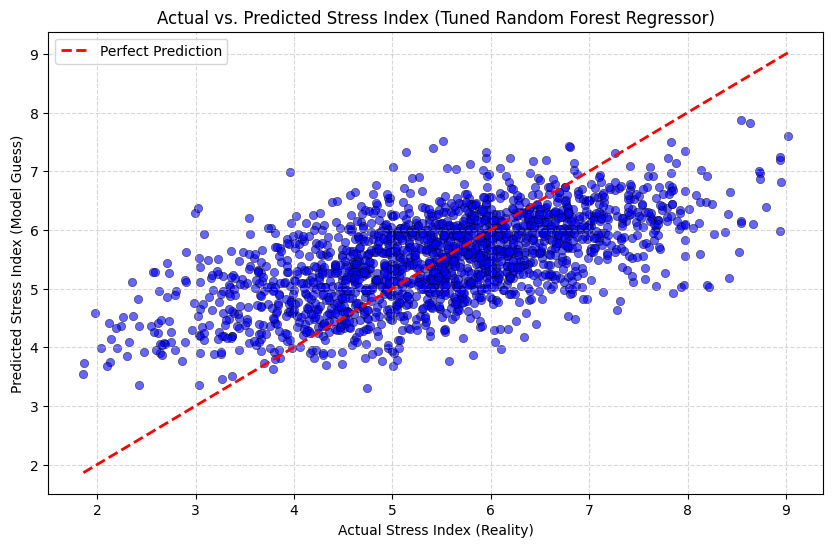

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Actual vs. Predicted for Tuned RandomForestRegressor
plt.figure(figsize=(10, 6))

# Scatter plot of real stress vs what the model guessed
sns.scatterplot(x=y_test, y=y_pred_tuned_rf, alpha=0.6, color='blue', edgecolor='k')

# Draw a perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred_tuned_rf.min())
max_val = max(y_test.max(), y_pred_tuned_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Stress Index (Tuned Random Forest Regressor)')
plt.xlabel('Actual Stress Index (Reality)')
plt.ylabel('Predicted Stress Index (Model Guess)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
predictions = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "KNN": y_pred_knn,
    "MLP": y_pred_mlp,
    "Bayesian Ridge": y_pred_bayesian,
    "AdaBoost": y_pred_ada
}

# Calculate metrics for each base model
results = []
for model_name, y_pred in predictions.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

base_results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

display(base_results_df)

,Model,RMSE,MAE,R2 Score
0,Random Forest,1.011093,0.807941,0.350565
1,XGBoost,1.020428,0.816102,0.338517
5,AdaBoost,1.032339,0.830001,0.322985
4,Bayesian Ridge,1.032627,0.828783,0.322607
3,MLP,1.094204,0.869170,0.239411
2,KNN,1.140293,0.902676,0.173987


In [ ]:
predictions = {
    "Random Forest (Tuned)": y_pred_tuned_rf,
    "XGBoost (Tuned)": y_pred_tuned_xgb,
    "KNN (Tuned)": y_pred_tuned_knn,
    "MLP (Tuned)": y_pred_tuned_mlp,
    "Bayesian Ridge (Tuned)": y_pred_tuned_bayesian,
    "AdaBoost (Tuned)": y_pred_tuned_ada
}

# Calculate metrics for each tuned model
results = []
for model_name, y_pred in predictions.items():
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

tuned_results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

display(tuned_results_df)

,Model,RMSE,MAE,R2 Score
0,Random Forest (Tuned),1.008474,0.805228,0.353925
1,XGBoost (Tuned),1.012972,0.809270,0.348149
5,AdaBoost (Tuned),1.032320,0.829944,0.323009
4,Bayesian Ridge (Tuned),1.032627,0.828783,0.322607
3,MLP (Tuned),1.033758,0.827829,0.321123
2,KNN (Tuned),1.069800,0.848648,0.272958


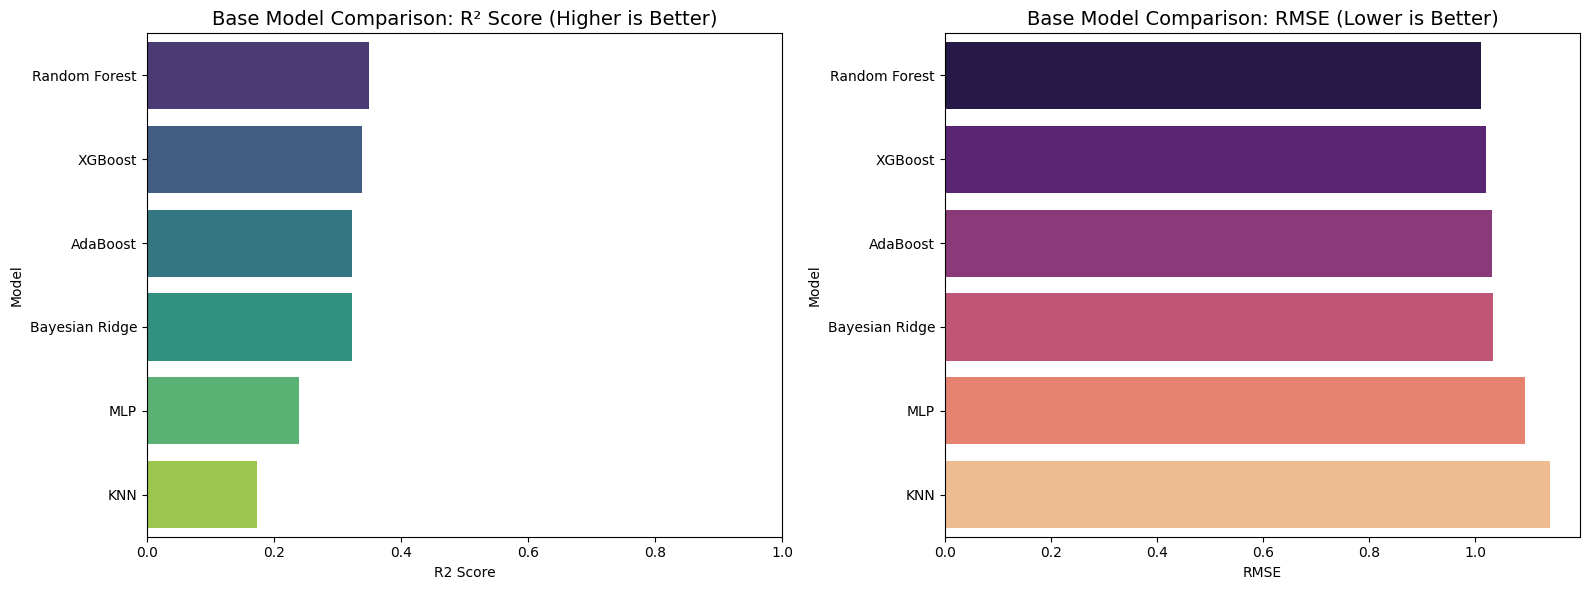

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Score
sns.barplot(data=base_results_df, x='R2 Score', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Base Model Comparison: R² Score (Higher is Better)', fontsize=14)
axes[0].set_xlim(0, 1.0) # Keeps the scale fixed if R2 is positive

# RMSE
sns.barplot(data=base_results_df.sort_values(by="RMSE", ascending=True), x='RMSE', y='Model', ax=axes[1], palette='magma')
axes[1].set_title('Base Model Comparison: RMSE (Lower is Better)', fontsize=14)

plt.tight_layout()
plt.show()

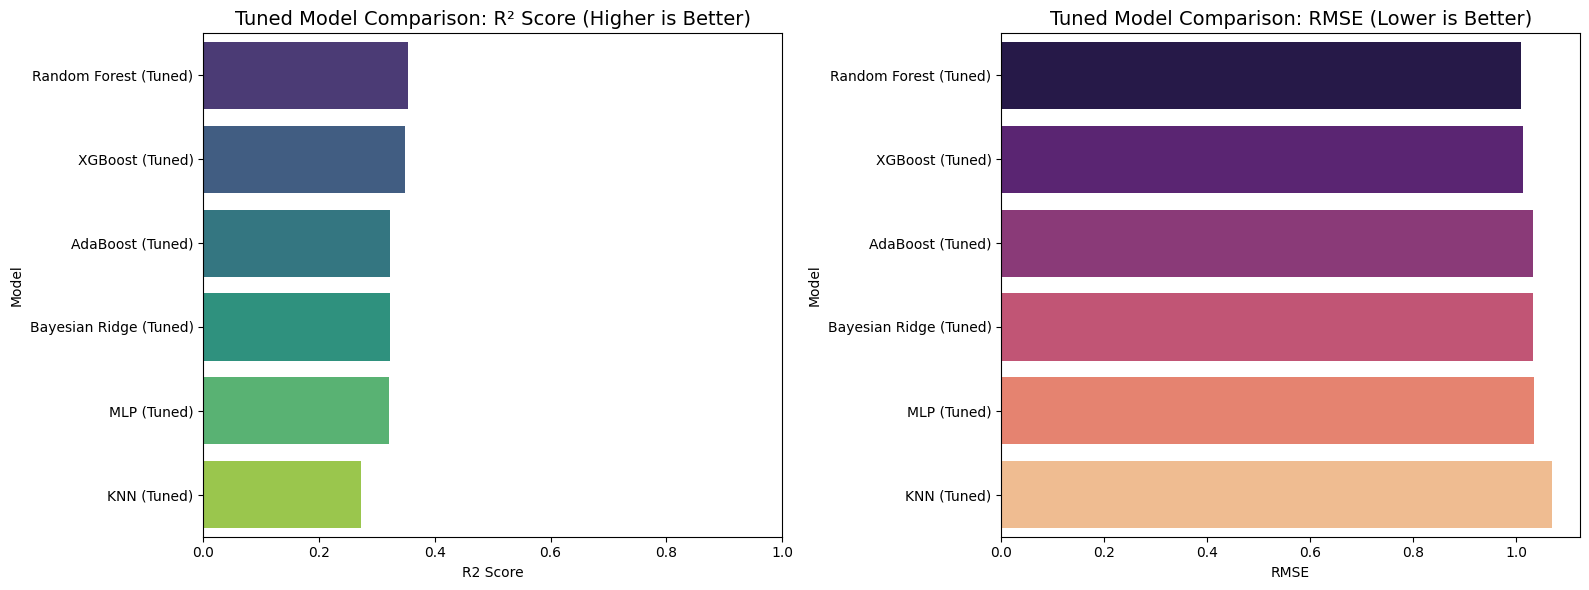

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 Score
sns.barplot(data=tuned_results_df, x='R2 Score', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Tuned Model Comparison: R² Score (Higher is Better)', fontsize=14)
axes[0].set_xlim(0, 1.0) # Keeps the scale fixed if R2 is positive

# RMSE
sns.barplot(data=tuned_results_df.sort_values(by="RMSE", ascending=True), x='RMSE', y='Model', ax=axes[1], palette='magma')
axes[1].set_title('Tuned Model Comparison: RMSE (Lower is Better)', fontsize=14)

plt.tight_layout()
plt.show()

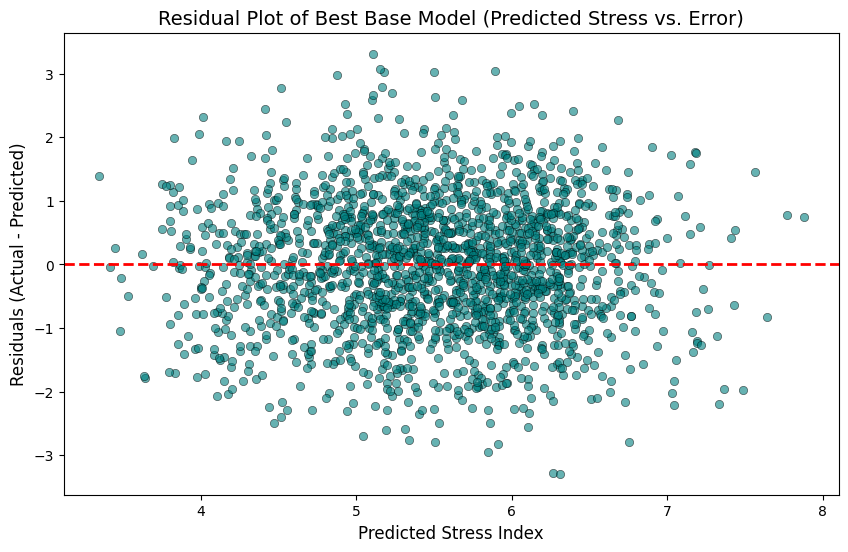

In [ ]:
best_base_predictions = y_pred_rf
residuals = y_test - best_base_predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=best_base_predictions, y=residuals, alpha=0.6, color='teal', edgecolor='k')

# Add a horizontal line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot of Best Base Model (Predicted Stress vs. Error)', fontsize=14)
plt.xlabel('Predicted Stress Index', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.show()

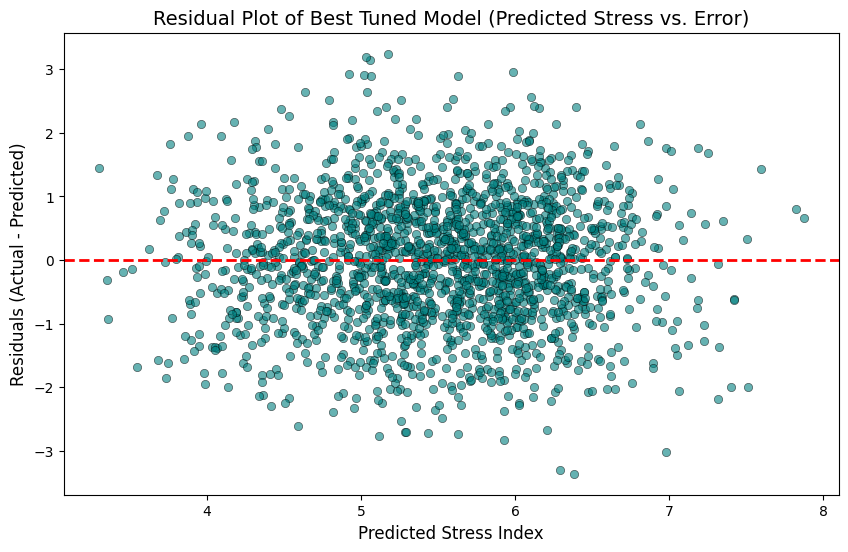

In [ ]:
best_tuned_predictions = y_pred_tuned_rf
residuals = y_test - best_tuned_predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=best_tuned_predictions, y=residuals, alpha=0.6, color='teal', edgecolor='k')

# Add a horizontal line at 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot of Best Tuned Model (Predicted Stress vs. Error)', fontsize=14)
plt.xlabel('Predicted Stress Index', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.show()